<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 828 | Val: 203 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[EfficientNet-B0] Epoch   1/100 | LR: 1.00e-04 | train loss 1.3117 acc 0.399 | val loss 1.1465 acc 0.571 *


[EfficientNet-B0] Epoch   2/100 | LR: 1.00e-04 | train loss 1.0065 acc 0.629 | val loss 0.8469 acc 0.650 *


[EfficientNet-B0] Epoch   3/100 | LR: 1.00e-04 | train loss 0.8318 acc 0.659 | val loss 0.6926 acc 0.759 *


[EfficientNet-B0] Epoch   4/100 | LR: 1.00e-04 | train loss 0.6415 acc 0.681 | val loss 0.5832 acc 0.759 *


...

[EfficientNet-B0] Epoch  17/100 | LR: 1.00e-05 | train loss 0.1603 acc 0.921 | val loss 0.4995 acc 0.847


[EfficientNet-B0] Epoch  18/100 | LR: 1.00e-05 | train loss 0.1168 acc 0.938 | val loss 0.4776 acc 0.837


[EfficientNet-B0] Epoch  19/100 | LR: 1.00e-05 | train loss 0.1452 acc 0.923 | val loss 0.4877 acc 0.837


[EfficientNet-B0] Epoch  20/100 | LR: 1.00e-05 | train loss 0.1124 acc 0.931 | val loss 0.5184 acc 0.842


[EfficientNet-B0] Epoch  21/100 | LR: 1.00e-05 | train loss 0.1352 acc 0.928 | val loss 0.4916 acc 0.823

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 21.

[EfficientNet-B0] Restored best checkpoint (val loss = 0.4250)


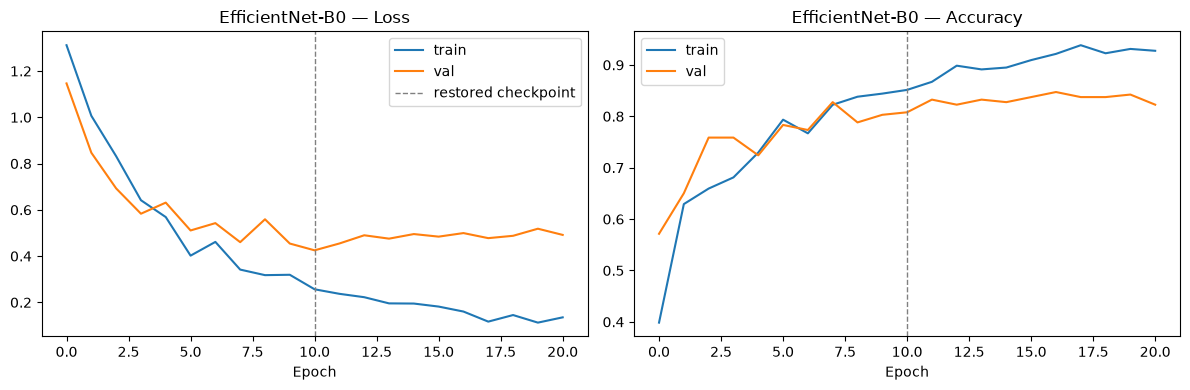

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.652


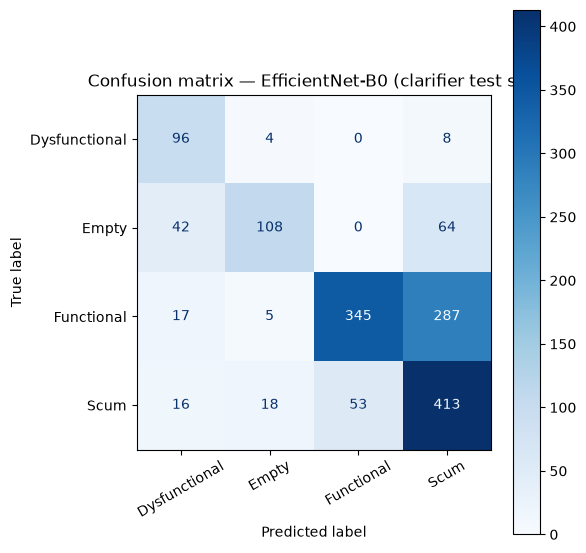

               precision    recall  f1-score   support

Dysfunctional      0.561     0.889     0.688       108
        Empty      0.800     0.505     0.619       214
   Functional      0.867     0.528     0.656       654
         Scum      0.535     0.826     0.649       500

     accuracy                          0.652      1476
    macro avg      0.691     0.687     0.653      1476
 weighted avg      0.722     0.652     0.651      1476



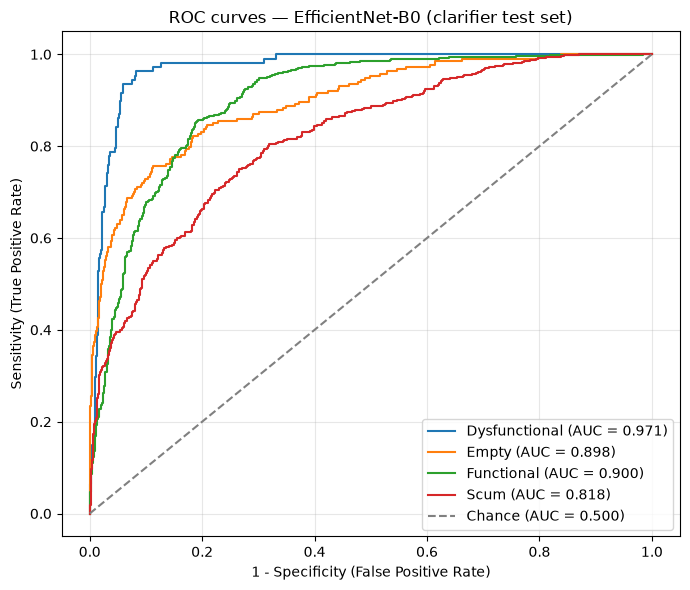

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.971
  Empty          : 0.898
  Functional     : 0.900
  Scum           : 0.818

Mean AUC (over 4/4 classes with test examples): 0.897


(np.float64(0.6517615176151762),
 {'Dysfunctional': 0.9706857808100497,
  'Empty': 0.8975109972303271,
  'Functional': 0.90020982611219,
  'Scum': 0.8184631147540983})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/results_clarifier_efficientnet_b0_CapeFlats.pkl


Saved model weights to ../models/clarifier_efficientnet_b0_cnn.pt
